In [2]:
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import albumentations as A
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    BatchNormalization, Dropout, GlobalAveragePooling2D
)

from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)
# import backbone for transfer learning
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras import layers, Model


In [3]:
file_path = '../../dataset/dataset_blood_group'

# List all classes in the dataset
name_class = os.listdir(file_path)
print(name_class)

['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


In [4]:
# Get file paths for all images in the dataset
filepaths = list(glob.glob(file_path + '/**/*.*'))

print(filepaths[-6:-1])

# Extract labels from file paths
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
print(labels)

['../../dataset/dataset_blood_group\\O-\\cluster_7_964.BMP', '../../dataset/dataset_blood_group\\O-\\cluster_7_977.BMP', '../../dataset/dataset_blood_group\\O-\\cluster_7_979.BMP', '../../dataset/dataset_blood_group\\O-\\cluster_7_985.BMP', '../../dataset/dataset_blood_group\\O-\\cluster_7_998.BMP']
['A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A

                                            Filepath Label
0  ../../dataset/dataset_blood_group\A-\cluster_1...    A-
1  ../../dataset/dataset_blood_group\B+\cluster_2...    B+
2  ../../dataset/dataset_blood_group\AB-\cluster_...   AB-
3  ../../dataset/dataset_blood_group\AB-\cluster_...   AB-
4  ../../dataset/dataset_blood_group\AB-\cluster_...   AB-


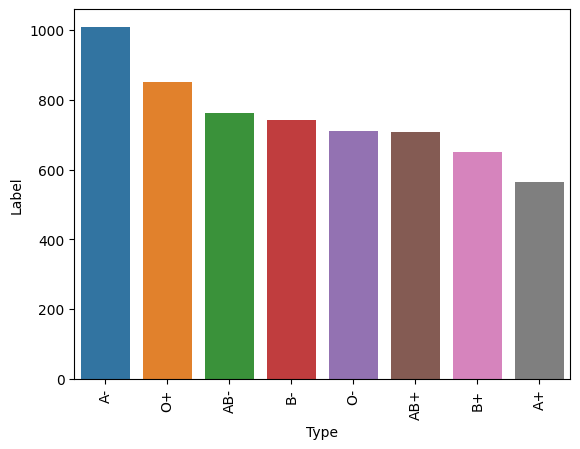

In [5]:
filepath = pd.Series(filepaths, name='Filepath').astype(str)
Labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, Labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
print(data.head(5))

counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90)
plt.show()

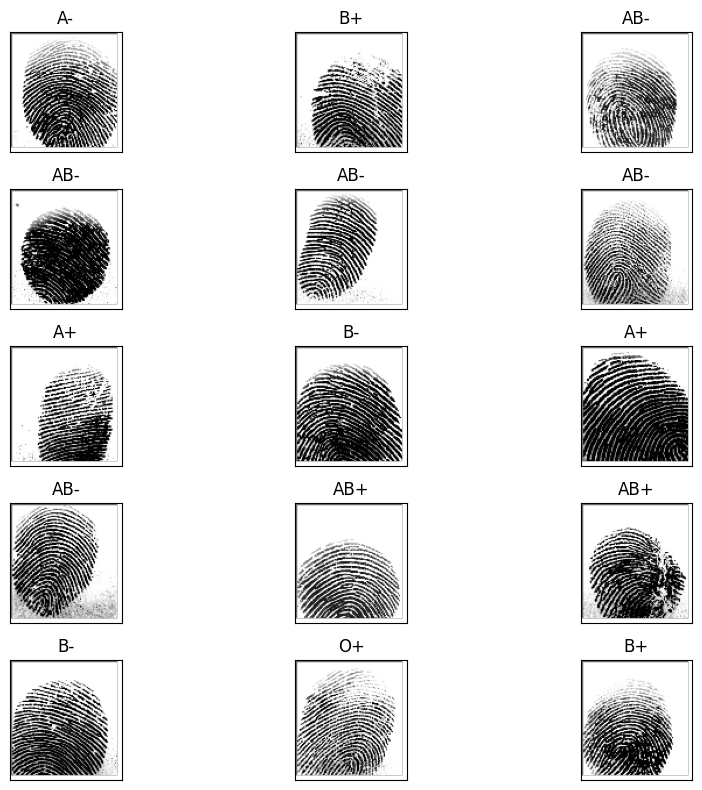

In [6]:
train, test = train_test_split(data, test_size=0.20, random_state=42)

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 8), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(data.Filepath[i]))
    ax.set_title(data.Label[i])
plt.tight_layout()
plt.show()

In [10]:
# Albumentations Transform for using data augmention

train_transform = A.Compose([

    A.Rotate(limit=15, p=0.5),

    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),

    A.RandomBrightnessContrast(0.1, 0.1, p=0.3),

    A.Normalize(),

])



# validation transform only normalizes

val_transform = A.Compose([A.Normalize()])





class AlbumentationsDataGenerator(Sequence):

    

    def __init__(self, dataframe, batch_size, target_size, transform=None, shuffle=True):

        self.dataframe = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.target_size = target_size

        self.transform = transform

        self.shuffle = shuffle

        self.indexes = np.arange(len(self.dataframe))

        self.classes = sorted(self.dataframe['Label'].unique())

        self.class_to_index = {c:i for i,c in enumerate(self.classes)}

        self.on_epoch_end()

        

    def __len__(self):

        return math.ceil(len(self.dataframe) / self.batch_size)

    

    def __getitem__(self, index):

        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        

        images = []

        labels = []

        

        for i in batch_indexes:

            img_path = self.dataframe.loc[i, 'Filepath']

            label = self.dataframe.loc[i, 'Label']

            

            image = cv2.imread(img_path)

            image = cv2.resize(image, (32,32))

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            

            if self.transform:

                augmented = self.transform(image=image)

                image = augmented['image']

            else:

                image = image / 255.0

            

            images.append(image)

            labels.append(self.class_to_index[label])

        

        return np.array(images), to_categorical(labels, num_classes=len(self.classes))

    

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(self.indexes)





train_gen = AlbumentationsDataGenerator(train, 32, (32,32), train_transform)

valid_gen = AlbumentationsDataGenerator(test, 32, (32,32), val_transform, shuffle=False)


In [11]:
# build an improved LeNet-like model with regularization

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),



    Conv2D(64, (3,3), activation='relu'),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),



    Flatten(),

    Dense(128, activation='relu'),

    BatchNormalization(),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(len(train_gen.classes), activation='softmax')

])



model.compile(

    optimizer="adam",

    loss='categorical_crossentropy',

    metrics=['accuracy']

)



# compute class weights to counter imbalance

labels_for_weights = train['Label'].map(train_gen.class_to_index)

weights_array = class_weight.compute_class_weight(

    'balanced',

    classes=np.arange(len(train_gen.classes)),

    y=labels_for_weights

)

class_weights = dict(enumerate(weights_array))

print('Class weights:', class_weights)



# callbacks to adjust LR, early stop and save best model

callbacks = [

    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),

    ModelCheckpoint('../../models/lenet_best.keras', monitor='val_loss', save_best_only=True)

]



history = model.fit(

    train_gen,

    validation_data=valid_gen,

    epochs=30,

    class_weight=class_weights,

    callbacks=callbacks

)


Class weights: {0: 1.348314606741573, 1: 0.7537688442211056, 2: 1.0309278350515463, 3: 0.9803921568627451, 4: 1.1627906976744187, 5: 1.0135135135135136, 6: 0.8797653958944281, 7: 1.0434782608695652}
Epoch 1/30
150/150 [==============================] - 7s 42ms/step - loss: 2.3367 - accuracy: 0.2333 - val_loss: 1.5494 - val_accuracy: 0.4367 - lr: 0.0010
Epoch 2/30
150/150 [==============================] - 4s 26ms/step - loss: 1.7550 - accuracy: 0.3527 - val_loss: 1.1665 - val_accuracy: 0.6175 - lr: 0.0010
Epoch 3/30
150/150 [==============================] - 4s 25ms/step - loss: 1.4143 - accuracy: 0.4677 - val_loss: 1.3164 - val_accuracy: 0.5650 - lr: 0.0010
Epoch 4/30
150/150 [==============================] - 4s 26ms/step - loss: 1.2798 - accuracy: 0.5242 - val_loss: 0.7435 - val_accuracy: 0.7425 - lr: 0.0010
Epoch 5/30
150/150 [==============================] - 4s 27ms/step - loss: 1.1768 - accuracy: 0.5765 - val_loss: 0.7397 - val_accuracy: 0.7492 - lr: 0.0010
Epoch 6/30
150/150 [=

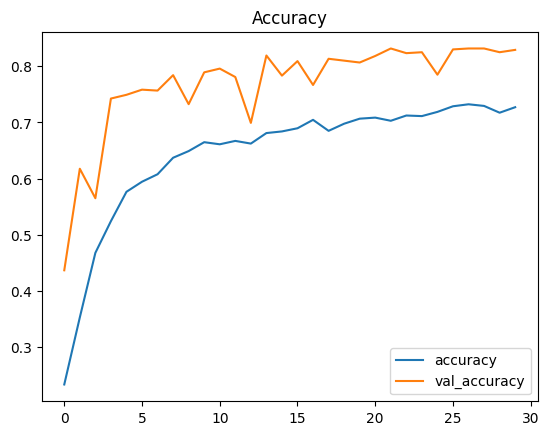

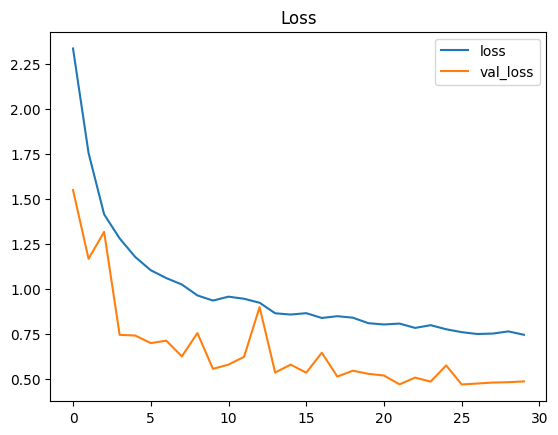

Test Loss: 0.48450
Test Accuracy: 82.92%
38/38 [==============================] - 1s 10ms/step
Pred length: 1200
True length: 1200
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       120
           1       0.87      0.77      0.82       213
           2       0.91      0.85      0.88       126
           3       0.76      0.85      0.80       149
           4       0.89      0.82      0.85       136
           5       0.82      0.89      0.85       149
           6       0.82      0.83      0.82       170
           7       0.72      0.83      0.77       137

    accuracy                           0.83      1200
   macro avg       0.84      0.83      0.83      1200
weighted avg       0.83      0.83      0.83      1200



In [12]:
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title("Loss")
plt.show()

results = model.evaluate(valid_gen, verbose=0)
print(f"Test Loss: {results[0]:.5f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

# Proper Prediction
pred_probs = model.predict(valid_gen)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = []
for i in range(len(valid_gen)):
    _, labels = valid_gen[i]
    true_classes.extend(np.argmax(labels, axis=1))

print("Pred length:", len(pred_classes))
print("True length:", len(true_classes))

from sklearn.metrics import classification_report
print(classification_report(true_classes, pred_classes))

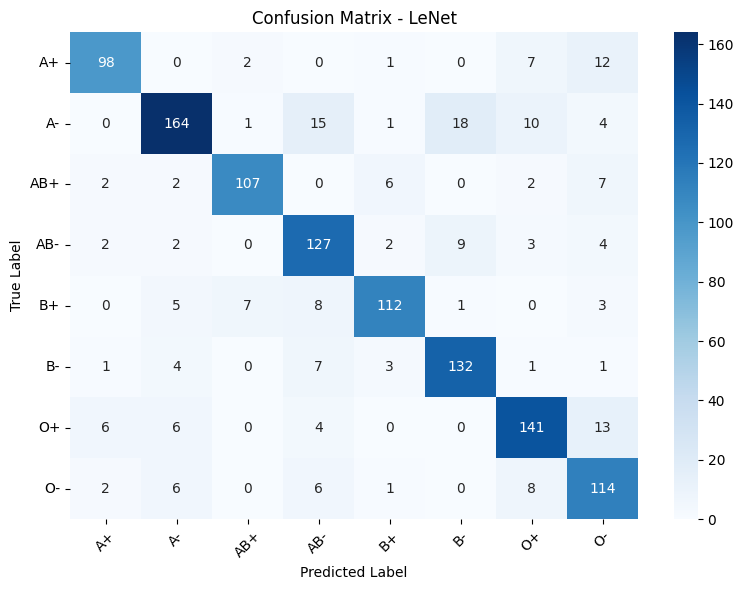

In [13]:
from sklearn.metrics import confusion_matrix

# Confusion matrix using true vs predicted classes
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=valid_gen.classes,
    yticklabels=valid_gen.classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LeNet')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# save the best model (already saved by checkpoint) and a final copy

model.save("../../models/lenet_final.keras")


1/1 [==============================] - 0s 60ms/step
Prediction: B+
Confidence: 87.84606456756592


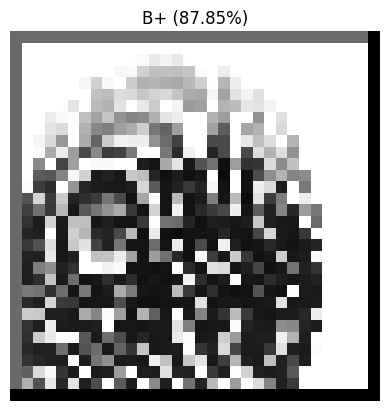

In [15]:
from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing import image



# load the model you intend to use for inference

model = load_model('../../models/lenet_final.keras')



labels_map = train_gen.class_to_index

labels_map = dict((v, k) for k, v in labels_map.items())



img_path = r"C:\Users\ASUS\Desktop\BD1\dataset\dataset_blood_group\AB-\cluster_5_31.BMP"



img = image.load_img(img_path, target_size=(32, 32))



x = image.img_to_array(img)

x = np.expand_dims(x, axis=0)

x = x / 255.0



result = model.predict(x)

predicted_class = np.argmax(result)



predicted_label = labels_map[predicted_class]

confidence = result[0][predicted_class] * 100



print("Prediction:", predicted_label)

print("Confidence:", confidence)



plt.imshow(img)

plt.axis('off')

plt.title(f"{predicted_label} ({confidence:.2f}%)")

plt.show()